# PyTorch ResNet50 with Patch Extraction

Train a ResNet50 regressor on fractal k_min prediction using grid patch extraction.

**Optimized for RTX 3050 Ti (4GB VRAM)**

In [1]:
from pathlib import Path
import gc
import json
import time
import tracemalloc
from functools import wraps

import numpy as np
import h5py
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.models as models
import torchvision.transforms as transforms

try:
    import psutil
except ImportError:
    psutil = None

try:
    from torchinfo import summary as model_summary
except ImportError:
    model_summary = None
    print('torchinfo not found – run: pip install torchinfo')

MEMORY_PROFILE_LOGS = []
ENABLE_MEMORY_PROFILING = True


def _get_rss_memory_mb():
    if psutil is not None:
        return psutil.Process().memory_info().rss / (1024 ** 2)

    try:
        import resource

        rss = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
        return rss / (1024 ** 2) if rss > 10 ** 7 else rss / 1024
    except Exception:
        return float('nan')


def _get_cuda_memory_snapshot():
    if not torch.cuda.is_available():
        return None

    torch.cuda.synchronize()
    return {
        'allocated_mb': torch.cuda.memory_allocated() / (1024 ** 2),
        'reserved_mb': torch.cuda.memory_reserved() / (1024 ** 2),
        'max_allocated_mb': torch.cuda.max_memory_allocated() / (1024 ** 2),
        'max_reserved_mb': torch.cuda.max_memory_reserved() / (1024 ** 2),
    }


def memory_profile(label=None, track_cuda=True):
    def decorator(func):
        @wraps(func)
        def wrapper(*args, **kwargs):
            if not ENABLE_MEMORY_PROFILING:
                return func(*args, **kwargs)

            gc.collect()
            rss_before = _get_rss_memory_mb()

            if track_cuda and torch.cuda.is_available():
                torch.cuda.synchronize()
                torch.cuda.reset_peak_memory_stats()
                cuda_before = _get_cuda_memory_snapshot()
            else:
                cuda_before = None

            tracemalloc.start()
            start = time.perf_counter()
            try:
                return func(*args, **kwargs)
            finally:
                if track_cuda and torch.cuda.is_available():
                    torch.cuda.synchronize()

                elapsed_s = time.perf_counter() - start
                _, python_peak_bytes = tracemalloc.get_traced_memory()
                tracemalloc.stop()
                rss_after = _get_rss_memory_mb()
                cuda_after = _get_cuda_memory_snapshot() if track_cuda else None

                record = {
                    'label': label or func.__name__,
                    'elapsed_s': round(float(elapsed_s), 3),
                    'rss_before_mb': round(float(rss_before), 2),
                    'rss_after_mb': round(float(rss_after), 2),
                    'rss_delta_mb': round(float(rss_after - rss_before), 2),
                    'python_peak_mb': round(float(python_peak_bytes / (1024 ** 2)), 2),
                }

                if cuda_before is not None and cuda_after is not None:
                    record.update({
                        'cuda_allocated_before_mb': round(float(cuda_before['allocated_mb']), 2),
                        'cuda_allocated_after_mb': round(float(cuda_after['allocated_mb']), 2),
                        'cuda_allocated_peak_mb': round(float(cuda_after['max_allocated_mb']), 2),
                        'cuda_reserved_before_mb': round(float(cuda_before['reserved_mb']), 2),
                        'cuda_reserved_after_mb': round(float(cuda_after['reserved_mb']), 2),
                        'cuda_reserved_peak_mb': round(float(cuda_after['max_reserved_mb']), 2),
                    })

                MEMORY_PROFILE_LOGS.append(record)

                message = (
                    f"[memory] {record['label']}: "
                    f"RSS {record['rss_before_mb']:.2f} -> {record['rss_after_mb']:.2f} MB "
                    f"(Δ {record['rss_delta_mb']:+.2f} MB), "
                    f"Python peak {record['python_peak_mb']:.2f} MB, "
                    f"time {record['elapsed_s']:.2f}s"
                )
                if 'cuda_allocated_peak_mb' in record:
                    message += (
                        f", CUDA alloc peak {record['cuda_allocated_peak_mb']:.2f} MB"
                        f", CUDA reserved peak {record['cuda_reserved_peak_mb']:.2f} MB"
                    )
                print(message)

        return wrapper

    return decorator


def summarize_memory_profiles(sort_key='elapsed_s'):
    if not MEMORY_PROFILE_LOGS:
        print('No memory profile data collected yet.')
        return []

    summary = sorted(
        MEMORY_PROFILE_LOGS,
        key=lambda item: item.get(sort_key, 0.0),
        reverse=True,
    )
    print('\nMemory profile summary:')
    for item in summary:
        line = (
            f"  - {item['label']}: "
            f"time={item['elapsed_s']:.2f}s | "
            f"ΔRSS={item['rss_delta_mb']:+.2f} MB | "
            f"py_peak={item['python_peak_mb']:.2f} MB"
        )
        if 'cuda_allocated_peak_mb' in item:
            line += f" | cuda_peak={item['cuda_allocated_peak_mb']:.2f} MB"
        print(line)
    return summary


# Setup
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

# Configuration
DATASET_DIR = Path('../../data/kmin_auto_batch')
OUTPUT_DIR = Path('../../outputs/pytorch_resnet')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RESOLUTIONS = [256, 512]
PATCH_SIZE = 128
MAX_PATCHES_PER_IMAGE = 2
BATCH_SIZE = 4
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-5
EPOCHS = 30
EARLY_STOP_PATIENCE = 5
SEED = 42

USE_PRETRAINED = False

np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print(f'\nConfig:\n  Batch: {BATCH_SIZE}\n  Patches: {MAX_PATCHES_PER_IMAGE}\n  Patch size: {PATCH_SIZE}x{PATCH_SIZE}\n  Dataset: {DATASET_DIR}')
print(f'  Memory profiling: {ENABLE_MEMORY_PROFILING}')
print(f'  Pretrained: {USE_PRETRAINED}')

Device: cuda
GPU: NVIDIA GeForce RTX 3050 Ti Laptop GPU
VRAM: 4.0 GB

Config:
  Batch: 4
  Patches: 2
  Patch size: 128x128
  Dataset: ../data/kmin_auto_batch
  Memory profiling: True
  Pretrained: False


In [2]:
def extract_grid_patches(image: np.ndarray, patch_size: int) -> np.ndarray:
    """Extract non-overlapping grid patches from image."""
    h, w = image.shape
    if h < patch_size or w < patch_size:
        return np.empty((0, patch_size, patch_size), dtype=np.float32)

    h_crop = (h // patch_size) * patch_size
    w_crop = (w // patch_size) * patch_size
    row_start = (h - h_crop) // 2
    col_start = (w - w_crop) // 2
    image = image[row_start:row_start + h_crop, col_start:col_start + w_crop]

    n_rows = h_crop // patch_size
    n_cols = w_crop // patch_size
    patches = (
        image
        .reshape(n_rows, patch_size, n_cols, patch_size)
        .transpose(0, 2, 1, 3)
        .reshape(-1, patch_size, patch_size)
    )
    return patches.astype(np.float32)


class HDF5PatchDataset(Dataset):
    """PyTorch Dataset for HDF5 patches."""
    
    def __init__(self, index_records, patch_size=128, max_patches=2, augment=False):
        self.records = index_records  # (file_path, resolution, image_idx, k_min)
        self.patch_size = patch_size
        self.max_patches = max_patches
        self.augment = augment
        
        # Augmentation
        if augment:
            self.transform = transforms.Compose([
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.RandomVerticalFlip(p=0.5),
            ])
        else:
            self.transform = None
    
    def __len__(self):
        return len(self.records)
    
    def __getitem__(self, idx):
        file_path, resolution, image_idx, k_min = self.records[idx]
        
        # Load image from HDF5
        group_key = f"{resolution}x{resolution}"
        with h5py.File(file_path, 'r') as f:
            img = f[f"{group_key}/images"][image_idx]
        
        # Extract patches
        patches = extract_grid_patches(img, self.patch_size)
        if self.max_patches is not None and len(patches) > self.max_patches:
            patches = patches[:self.max_patches]
        
        # Normalize to [0, 1]
        patches = patches.astype(np.float32) / 255.0
        
        # Return first patch (or random if augmenting)
        if len(patches) == 0:
            patch = np.zeros((self.patch_size, self.patch_size), dtype=np.float32)
        else:
            patch_idx = np.random.randint(0, len(patches)) if self.augment else 0
            patch = patches[patch_idx]
        
        # Convert to 3 channels
        patch = np.stack([patch, patch, patch], axis=0)  # (3, H, W)
        
        # Augmentation
        if self.transform:
            patch = torch.from_numpy(patch)
            patch = self.transform(patch)
        else:
            patch = torch.from_numpy(patch)
        
        label = torch.tensor(k_min, dtype=torch.float32)
        return patch, label


## Data Loading

In [ ]:
# Discover and index HDF5 files
h5_files = sorted(DATASET_DIR.glob('*.h5'))
print(f'Found {len(h5_files)} HDF5 files')

records = []
for fpath in h5_files:
    try:
        with h5py.File(fpath, 'r') as f:
            for res in RESOLUTIONS:
                group_key = f'{res}x{res}'
                if group_key not in f:
                    continue
                n_images = f[group_key].attrs.get('num_images', 0)
                k_min_arr = f[f'{group_key}/parameters/k_min'][:]
                for idx in range(int(n_images)):
                    records.append((str(fpath), res, idx, float(k_min_arr[idx])))
    except Exception as e:
        print(f'Warning: {fpath}: {e}')

print(f'Total indexed samples: {len(records)}')

# Convert to structured array for easy indexing
records_arr = np.array(
    records,
    dtype=[('file_path', 'U256'), ('resolution', np.int32),
            ('image_idx', np.int32), ('k_min', np.float32)]
)

# Stratified split
idx = np.arange(len(records_arr))
k_min_vals = records_arr['k_min']
bins = np.linspace(k_min_vals.min(), k_min_vals.max() + 1e-6, 32 + 1)
strata = np.digitize(k_min_vals, bins)

idx_train, idx_temp = train_test_split(
    idx, test_size=0.30, stratify=strata, random_state=SEED
)
strata_temp = strata[idx_temp]
idx_val, idx_test = train_test_split(
    idx_temp, test_size=0.50, stratify=strata_temp, random_state=SEED
)

train_records = records_arr[idx_train].tolist()
val_records = records_arr[idx_val].tolist()
test_records = records_arr[idx_test].tolist()

print(f'\nSplit:\n  Train: {len(train_records)}\n  Val: {len(val_records)}\n  Test: {len(test_records)}')

# Create datasets (dataset is pre-balanced, no weighted sampler needed)
train_dataset = HDF5PatchDataset(train_records, patch_size=PATCH_SIZE, max_patches=MAX_PATCHES_PER_IMAGE, augment=True)
val_dataset = HDF5PatchDataset(val_records, patch_size=PATCH_SIZE, max_patches=MAX_PATCHES_PER_IMAGE, augment=False)
test_dataset = HDF5PatchDataset(test_records, patch_size=PATCH_SIZE, max_patches=MAX_PATCHES_PER_IMAGE, augment=False)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)

print(f'\nDataLoaders created')
print(f'  Train batches: {len(train_loader)}')
print(f'  Val batches: {len(val_loader)}')
print(f'  Test batches: {len(test_loader)}')

Found 32 HDF5 files
Total indexed samples: 64000

Split:
  Train: 44800
  Val: 9600
  Test: 9600

DataLoaders created
  Train batches: 11200
  Val batches: 2400
  Test batches: 2400


## Build Model

In [4]:
class ResNet50Regressor(nn.Module):
    """ResNet50 for regression (all layers trainable)."""

    def __init__(self, pretrained=False):
        super().__init__()
        weights = models.ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
        self.backbone = models.resnet50(weights=weights)

        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(256),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
        )

    def forward(self, x):
        return self.backbone(x)


model = ResNet50Regressor(pretrained=USE_PRETRAINED).to(DEVICE)

# Model summary
if model_summary is not None:
    model_summary(
        model,
        input_size=(BATCH_SIZE, 3, PATCH_SIZE, PATCH_SIZE),
        col_names=['input_size', 'output_size', 'num_params', 'trainable'],
        row_settings=['var_names'],
        device=DEVICE,
    )
else:
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print('Model: ResNet50 Regressor')
    print(f'  Total params: {total_params:,}')
    print(f'  Trainable params: {trainable_params:,}')
    print('  (install torchinfo for a full layer-by-layer summary)')

# Optimizer and loss
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
loss_fn = nn.SmoothL1Loss(beta=1.0)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6
)

print('\n✓ Model, optimizer, scheduler ready')


✓ Model, optimizer, scheduler ready


## Training Loop

In [5]:
@memory_profile('train_epoch')
def train_epoch(model, loader, optimizer, loss_fn, device):
    """Train one epoch."""
    model.train()
    total_loss = 0

    for images, labels in tqdm(loader, desc='Training', leave=False):
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

    return total_loss / len(loader.dataset)


@memory_profile('eval_epoch')
def eval_epoch(model, loader, loss_fn, device):
    """Evaluate one epoch."""
    model.eval()
    total_loss = 0
    predictions = []
    targets = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Evaluating', leave=False):
            images = images.to(device)
            labels = labels.to(device).unsqueeze(1)

            outputs = model(images)
            loss = loss_fn(outputs, labels)

            total_loss += loss.item() * images.size(0)
            predictions.extend(outputs.cpu().numpy().flatten())
            targets.extend(labels.cpu().numpy().flatten())

    loss = total_loss / len(loader.dataset)
    mae = np.mean(np.abs(np.array(predictions) - np.array(targets)))
    rmse = np.sqrt(np.mean((np.array(predictions) - np.array(targets)) ** 2))

    return float(loss), float(mae), float(rmse), np.array(predictions), np.array(targets)


def get_kernel_stats(model):
    conv1 = model.backbone.conv1.weight.detach()
    conv_last = model.backbone.layer4[-1].conv3.weight.detach()
    return {
        'conv1_l2': float(torch.norm(conv1).item()),
        'conv_last_l2': float(torch.norm(conv_last).item()),
        'conv1': conv1.clone(),
        'conv_last': conv_last.clone(),
    }


# Training
print(f'\nStarting training for {EPOCHS} epochs...\n')

history = {
    'train_loss': [],
    'val_loss': [],
    'val_mae': [],
    'val_rmse': [],
    'conv1_l2': [],
    'conv_last_l2': [],
    'conv1_delta': [],
    'conv_last_delta': [],
}
best_val_loss = float('inf')
patience_counter = 0

prev_stats = get_kernel_stats(model)

for epoch in range(EPOCHS):
    train_loss = train_epoch(model, train_loader, optimizer, loss_fn, DEVICE)
    val_loss, val_mae, val_rmse, val_preds, val_targets = eval_epoch(model, val_loader, loss_fn, DEVICE)

    current_stats = get_kernel_stats(model)
    conv1_delta = float((current_stats['conv1'] - prev_stats['conv1']).abs().mean().item())
    conv_last_delta = float((current_stats['conv_last'] - prev_stats['conv_last']).abs().mean().item())

    history['train_loss'].append(float(train_loss))
    history['val_loss'].append(float(val_loss))
    history['val_mae'].append(float(val_mae))
    history['val_rmse'].append(float(val_rmse))
    history['conv1_l2'].append(current_stats['conv1_l2'])
    history['conv_last_l2'].append(current_stats['conv_last_l2'])
    history['conv1_delta'].append(conv1_delta)
    history['conv_last_delta'].append(conv_last_delta)

    scheduler.step(val_loss)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | MAE: {val_mae:.4f} | RMSE: {val_rmse:.4f} | "
        f"Δconv1: {conv1_delta:.6f} | ΔconvL: {conv_last_delta:.6f}"
    )

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), OUTPUT_DIR / 'best_model.pth')
    else:
        patience_counter += 1
        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f'\nEarly stopping at epoch {epoch+1}')
            break

    prev_stats = current_stats

print('\n✓ Training complete')

# Save history
history_serializable = {
    key: [float(v) for v in values]
    for key, values in history.items()
}
with open(OUTPUT_DIR / 'history.json', 'w') as f:
    json.dump(history_serializable, f, indent=2)


Starting training for 30 epochs...



[memory] train_epoch: RSS 1525.21 -> 1741.08 MB (Δ +215.87 MB), Python peak 2.83 MB, time 397.79s, CUDA alloc peak 492.57 MB, CUDA reserved peak 522.00 MB


[memory] eval_epoch: RSS 1741.08 -> 1742.02 MB (Δ +0.94 MB), Python peak 0.84 MB, time 27.32s, CUDA alloc peak 409.01 MB, CUDA reserved peak 522.00 MB
Epoch 1/30 | Train Loss: 6.1497 | Val Loss: 33.6820 | MAE: 34.1547 | RMSE: 138.0052 | Δconv1: 0.006153 | ΔconvL: 0.006445


[memory] train_epoch: RSS 1752.14 -> 1747.96 MB (Δ -4.19 MB), Python peak 2.72 MB, time 401.38s, CUDA alloc peak 491.94 MB, CUDA reserved peak 522.00 MB


[memory] eval_epoch: RSS 1747.96 -> 1748.71 MB (Δ +0.75 MB), Python peak 0.86 MB, time 28.01s, CUDA alloc peak 409.01 MB, CUDA reserved peak 522.00 MB
Epoch 2/30 | Train Loss: 4.5044 | Val Loss: 4.4146 | MAE: 4.8805 | RMSE: 7.2122 | Δconv1: 0.006471 | ΔconvL: 0.006234


...

[memory] eval_epoch: RSS 1739.45 -> 1739.80 MB (Δ +0.36 MB), Python peak 0.85 MB, time 25.90s, CUDA alloc peak 409.01 MB, CUDA reserved peak 522.00 MB
Epoch 8/30 | Train Loss: 4.1641 | Val Loss: 10.4617 | MAE: 10.9420 | RMSE: 42.8845 | Δconv1: 0.002903 | ΔconvL: 0.003623


[memory] train_epoch: RSS 1739.80 -> 1527.46 MB (Δ -212.35 MB), Python peak 2.68 MB, time 402.29s, CUDA alloc peak 492.57 MB, CUDA reserved peak 522.00 MB


[memory] eval_epoch: RSS 1527.46 -> 1527.46 MB (Δ +0.00 MB), Python peak 0.84 MB, time 28.93s, CUDA alloc peak 409.01 MB, CUDA reserved peak 522.00 MB
Epoch 9/30 | Train Loss: 4.1845 | Val Loss: 2.9080 | MAE: 3.3708 | RMSE: 4.6187 | Δconv1: 0.003646 | ΔconvL: 0.004160


[memory] train_epoch: RSS 1527.46 -> 1527.54 MB (Δ +0.08 MB), Python peak 1.93 MB, time 13.75s, CUDA alloc peak 491.94 MB, CUDA reserved peak 522.00 MB


KeyboardInterrupt: 

## Evaluation

In [ ]:
# Load best model
model.load_state_dict(torch.load(OUTPUT_DIR / 'best_model.pth'))

# Evaluate on test set
print('Evaluating on test set...')
test_loss, test_mae, test_rmse, test_preds, test_targets = eval_epoch(model, test_loader, loss_fn, DEVICE)

test_metrics = {
    'loss': float(test_loss),
    'mae': float(test_mae),
    'rmse': float(test_rmse),
}

print(f'\nTest Metrics:')
for k, v in test_metrics.items():
    print(f'  {k}: {v:.4f}')

with open(OUTPUT_DIR / 'test_metrics.json', 'w') as f:
    json.dump(test_metrics, f, indent=2)

Evaluating on test set...



Test Metrics:
  loss: 2.4919
  mae: 2.9270
  rmse: 4.2880


## Visualization

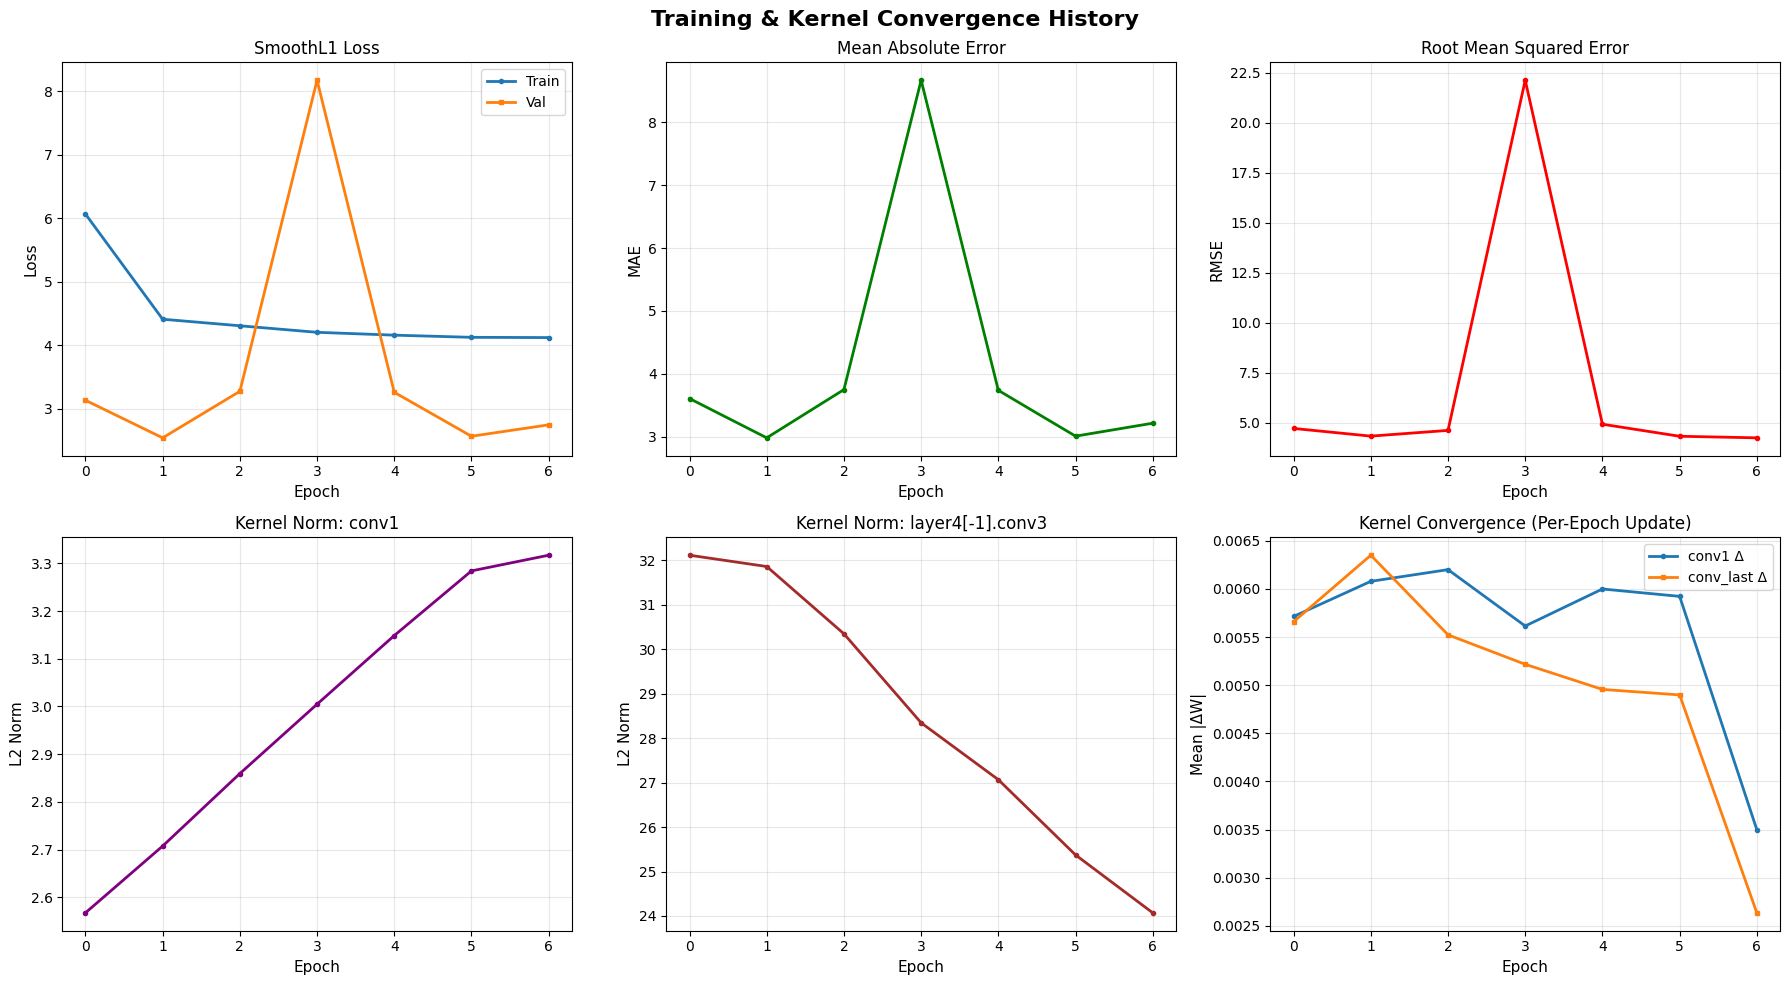

✓ Curves saved


In [ ]:
# Plot training + kernel convergence curves
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Training & Kernel Convergence History', fontsize=16, fontweight='bold')

# Loss
ax = axes[0, 0]
ax.plot(history['train_loss'], label='Train', linewidth=2, marker='o', markersize=3)
ax.plot(history['val_loss'], label='Val', linewidth=2, marker='s', markersize=3)
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Loss', fontsize=11)
ax.set_title('SmoothL1 Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# MAE
ax = axes[0, 1]
ax.plot(history['val_mae'], label='Val MAE', linewidth=2, marker='o', markersize=3, color='green')
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('MAE', fontsize=11)
ax.set_title('Mean Absolute Error')
ax.grid(True, alpha=0.3)

# RMSE
ax = axes[0, 2]
ax.plot(history['val_rmse'], label='Val RMSE', linewidth=2, marker='o', markersize=3, color='red')
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('RMSE', fontsize=11)
ax.set_title('Root Mean Squared Error')
ax.grid(True, alpha=0.3)

# Conv1 L2 norm
ax = axes[1, 0]
ax.plot(history['conv1_l2'], linewidth=2, marker='o', markersize=3, color='purple')
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('L2 Norm', fontsize=11)
ax.set_title('Kernel Norm: conv1')
ax.grid(True, alpha=0.3)

# Last conv L2 norm
ax = axes[1, 1]
ax.plot(history['conv_last_l2'], linewidth=2, marker='o', markersize=3, color='brown')
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('L2 Norm', fontsize=11)
ax.set_title('Kernel Norm: layer4[-1].conv3')
ax.grid(True, alpha=0.3)

# Kernel update deltas
ax = axes[1, 2]
ax.plot(history['conv1_delta'], label='conv1 Δ', linewidth=2, marker='o', markersize=3)
ax.plot(history['conv_last_delta'], label='conv_last Δ', linewidth=2, marker='s', markersize=3)
ax.set_xlabel('Epoch', fontsize=11)
ax.set_ylabel('Mean |ΔW|', fontsize=11)
ax.set_title('Kernel Convergence (Per-Epoch Update)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'training_kernel_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

print('✓ Curves saved')

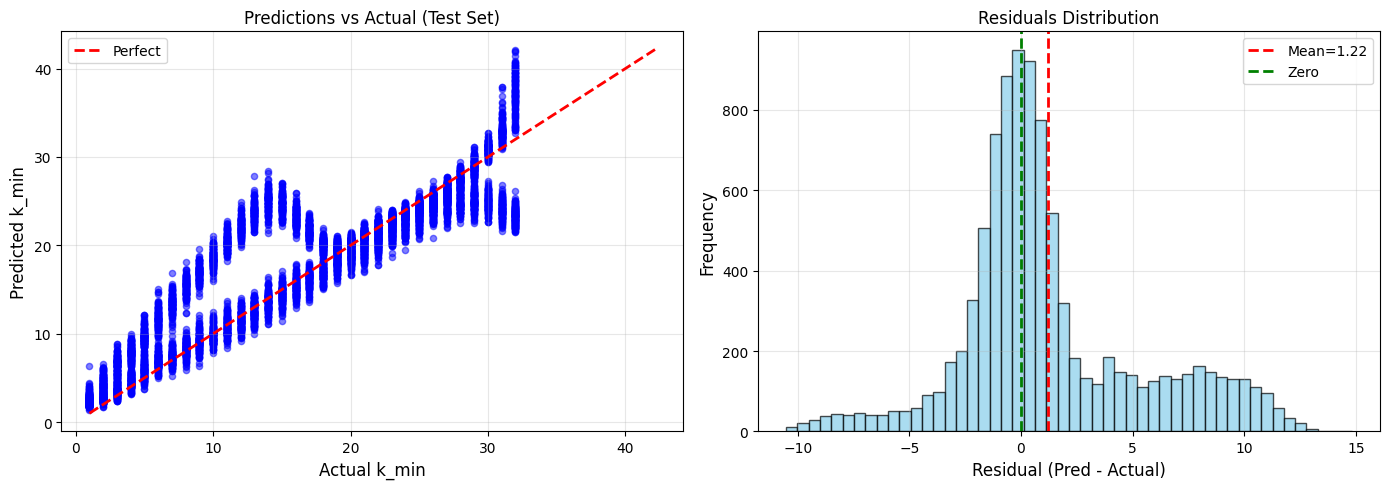


Test Set Stats:
  MAE: 2.9270
  RMSE: 4.2880
  Residual mean: 1.2230
  Residual std: 4.1099


In [ ]:
# Get predictions on test set
model.eval()
all_preds = []
all_targets = []
all_images = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        outputs = model(images).cpu().numpy().flatten()
        all_preds.extend(outputs)
        all_targets.extend(labels.numpy())
        all_images.extend(images.cpu().numpy())

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)
all_images = np.array(all_images)
residuals = all_preds - all_targets

# Predictions vs actual
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter(all_targets, all_preds, alpha=0.5, s=20, color='blue')
lims = [min(all_targets.min(), all_preds.min()), max(all_targets.max(), all_preds.max())]
ax.plot(lims, lims, 'r--', lw=2, label='Perfect')
ax.set_xlabel('Actual k_min', fontsize=12)
ax.set_ylabel('Predicted k_min', fontsize=12)
ax.set_title('Predictions vs Actual (Test Set)')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='skyblue')
ax.axvline(residuals.mean(), color='r', linestyle='--', linewidth=2, label=f'Mean={residuals.mean():.2f}')
ax.axvline(0, color='g', linestyle='--', linewidth=2, label='Zero')
ax.set_xlabel('Residual (Pred - Actual)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Residuals Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'test_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nTest Set Stats:')
print(f'  MAE: {np.mean(np.abs(residuals)):.4f}')
print(f'  RMSE: {np.sqrt(np.mean(residuals**2)):.4f}')
print(f'  Residual mean: {residuals.mean():.4f}')
print(f'  Residual std: {residuals.std():.4f}')

## Confusion Matrices (Binned and Rounded k_min)

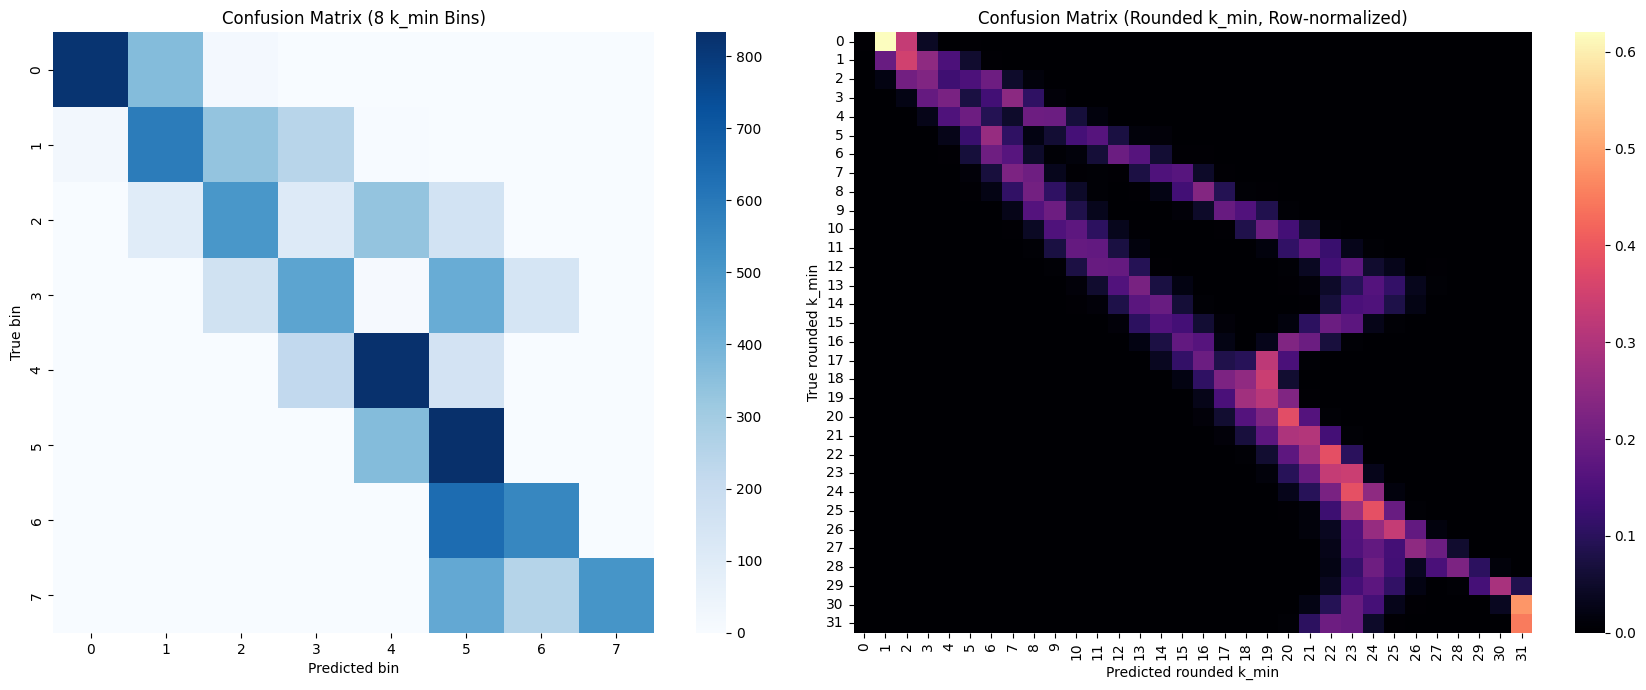

✓ Confusion matrices saved


In [ ]:
# Build discrete labels from regression outputs for confusion-matrix diagnostics
true_rounded = np.clip(np.rint(all_targets), 1, 32).astype(int)
pred_rounded = np.clip(np.rint(all_preds), 1, 32).astype(int)

# Coarser binned classes (8 bins) for cleaner global confusion view
bin_edges = np.linspace(1, 33, 9)  # [1..32] split into 8 bins
true_bins = np.digitize(all_targets, bin_edges[1:-1], right=False)
pred_bins = np.digitize(all_preds, bin_edges[1:-1], right=False)

cm_round = confusion_matrix(true_rounded, pred_rounded, labels=np.arange(1, 33))
cm_bins = confusion_matrix(true_bins, pred_bins, labels=np.arange(8))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(
    cm_bins,
    ax=axes[0],
    cmap='Blues',
    cbar=True,
    square=True,
)
axes[0].set_title('Confusion Matrix (8 k_min Bins)')
axes[0].set_xlabel('Predicted bin')
axes[0].set_ylabel('True bin')

# Normalize rounded confusion by row for readability
cm_round_norm = cm_round.astype(np.float32)
row_sums = cm_round_norm.sum(axis=1, keepdims=True) + 1e-8
cm_round_norm = cm_round_norm / row_sums

sns.heatmap(
    cm_round_norm,
    ax=axes[1],
    cmap='magma',
    cbar=True,
)
axes[1].set_title('Confusion Matrix (Rounded k_min, Row-normalized)')
axes[1].set_xlabel('Predicted rounded k_min')
axes[1].set_ylabel('True rounded k_min')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

print('✓ Confusion matrices saved')

## Grad-CAM Analysis (ResNet50 layer4)

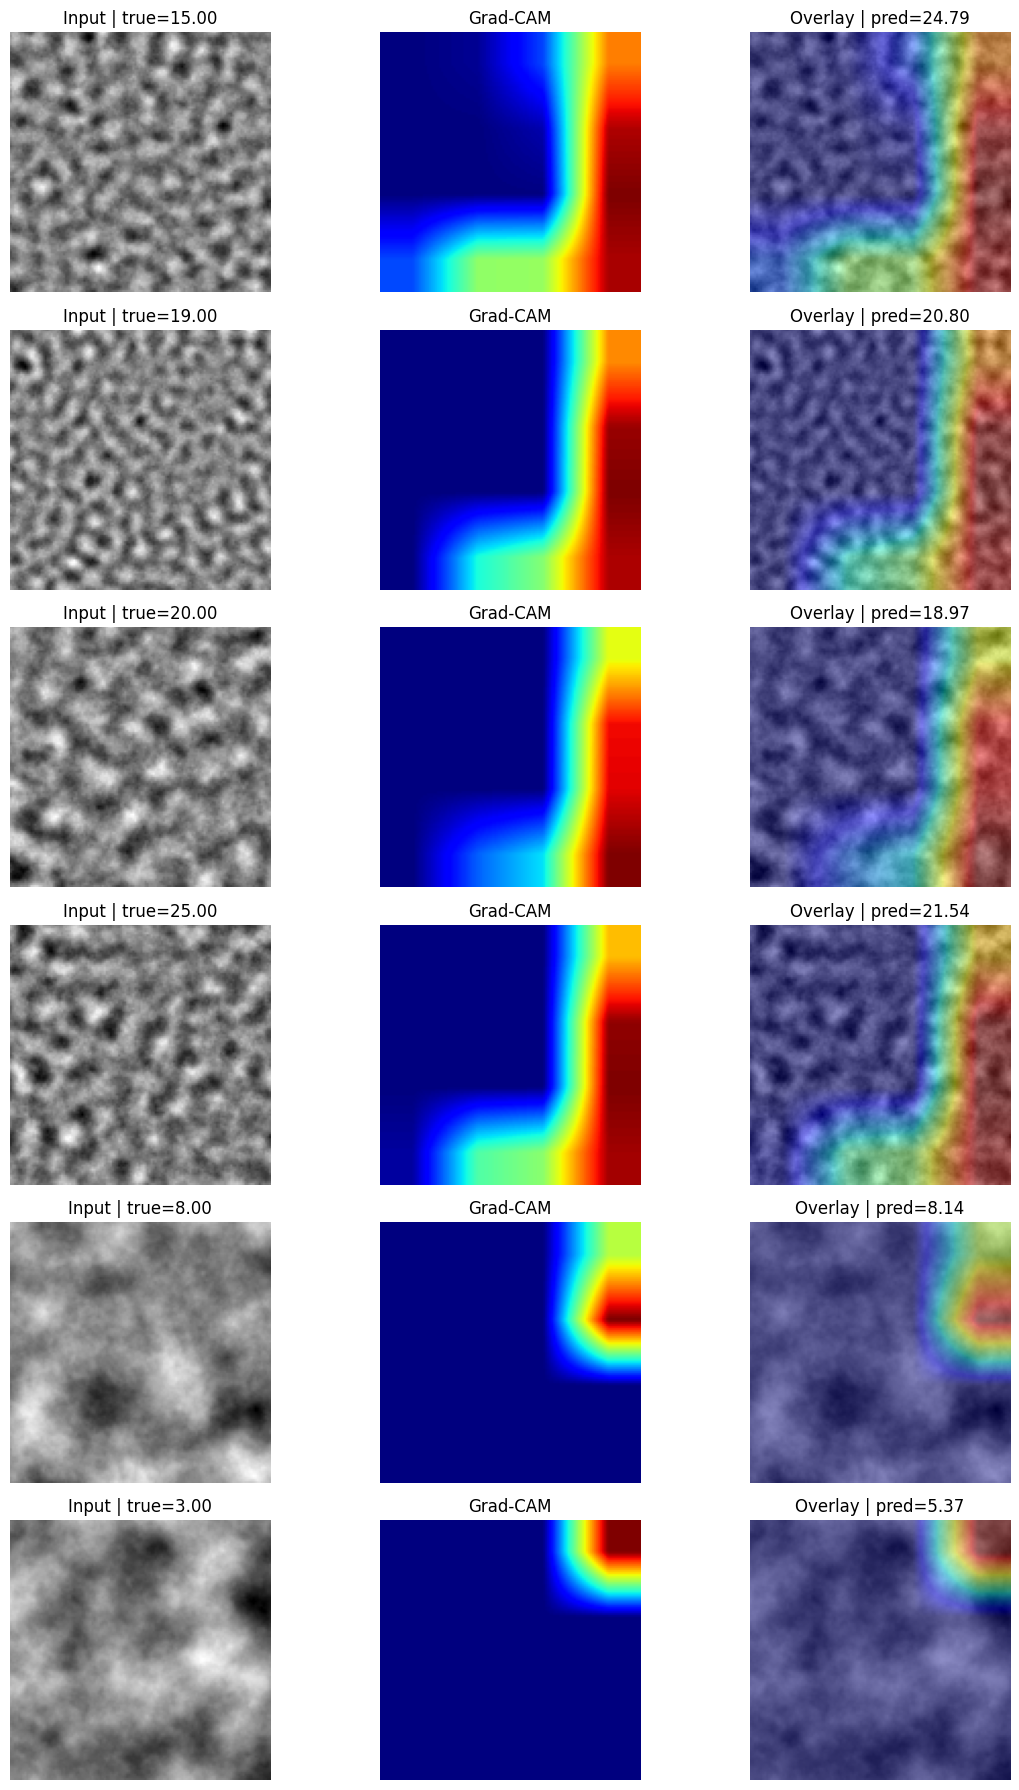

✓ Grad-CAM examples saved


In [ ]:
def compute_gradcam(model, input_tensor, target_layer):
    activations = []
    gradients = []

    def forward_hook(module, inp, out):
        activations.append(out.detach())

    def backward_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0].detach())

    h1 = target_layer.register_forward_hook(forward_hook)
    h2 = target_layer.register_full_backward_hook(backward_hook)

    model.eval()
    output = model(input_tensor)
    score = output[:, 0].sum()

    model.zero_grad(set_to_none=True)
    score.backward()

    acts = activations[0]
    grads = gradients[0]

    weights = grads.mean(dim=(2, 3), keepdim=True)
    cam = (weights * acts).sum(dim=1, keepdim=True)
    cam = torch.relu(cam)
    cam = torch.nn.functional.interpolate(
        cam,
        size=(input_tensor.shape[2], input_tensor.shape[3]),
        mode='bilinear',
        align_corners=False,
    )
    cam = cam.squeeze().cpu().numpy()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

    h1.remove()
    h2.remove()
    return cam, float(output.detach().cpu().numpy().squeeze())


# Visualize Grad-CAM for a few test samples
target_layer = model.backbone.layer4[-1].conv3
num_examples = min(6, len(all_images))
example_idx = np.linspace(0, len(all_images) - 1, num_examples, dtype=int)

fig, axes = plt.subplots(num_examples, 3, figsize=(12, 3 * num_examples))
if num_examples == 1:
    axes = np.expand_dims(axes, axis=0)

for row, idx in enumerate(example_idx):
    image_np = all_images[idx]  # (3,H,W)
    image_tensor = torch.tensor(image_np[None, ...], dtype=torch.float32, device=DEVICE)

    cam, pred_val = compute_gradcam(model, image_tensor, target_layer)
    image_hwc = np.transpose(image_np, (1, 2, 0))
    image_gray = image_hwc.mean(axis=2)

    axes[row, 0].imshow(image_gray, cmap='gray')
    axes[row, 0].set_title(f'Input | true={all_targets[idx]:.2f}')
    axes[row, 0].axis('off')

    axes[row, 1].imshow(cam, cmap='jet')
    axes[row, 1].set_title('Grad-CAM')
    axes[row, 1].axis('off')

    axes[row, 2].imshow(image_gray, cmap='gray')
    axes[row, 2].imshow(cam, cmap='jet', alpha=0.45)
    axes[row, 2].set_title(f'Overlay | pred={pred_val:.2f}')
    axes[row, 2].axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'gradcam_examples.png', dpi=150, bbox_inches='tight')
plt.show()

print('✓ Grad-CAM examples saved')

In [ ]:
profile_summary = summarize_memory_profiles()

if profile_summary:
    with open(OUTPUT_DIR / 'memory_profiles.json', 'w') as f:
        json.dump(profile_summary, f, indent=2)
    print(f"\n✓ Saved memory profiles to {OUTPUT_DIR / 'memory_profiles.json'}")